# 3H - Genese: que estado fisico precede o onset e separa fortes de fracos?

**Pergunta especifica.** Que valores as variaveis assumem ANTES do onset de cada evento, e o estado precursor separa, ja na genese, os que viram super/strong dos moderate/weak?

**Objetivo.** Compostos alinhados ao ONSET (nao ao pico) e ordenamento da intensidade final pelo estado precursor.

**Justificativa.** 3C-3E mediram associacao com a SSTA continua; 3H alinha ao nascimento do evento. Com n=12 e leitura descritiva (Spearman, ranges), sem p-valores agressivos. **Area:** caixa Nino 3.4 (WWV no Pac. equatorial).

**Metodologia.** Compostos -52..+78 sem do onset por grupo (forte=super+strong n=6; fraco=moderate+weak n=6); estado precursor em -26/-13/0 sem; Spearman(estado precursor -26..0, intensidade final).

**Saidas.** `phase3H_proveniencia_eventos.csv`, `phase3H_estado_precursor_por_classe.csv`, `phase3H_separacao_genese.csv` + compostos, storyline e retrato.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev=u.load_events(); ev['grupo']=np.where(ev['peak_class'].isin(['super_el_nino','strong_el_nino']),'forte','fraco')
prov=ev[['event_id','peak_class','grupo','event_start','peak_time','event_end','duration_months','peak_monthly_ssta_c']].copy()
prov.columns=['evento','classe','grupo_composto','onset','pico','fim','duracao_meses','ssta_pico_c']
u.save_table(prov,'phase3H_proveniencia_eventos.csv',index=False)
print('PROVENIENCIA - forte n=%d, fraco n=%d'%(len(prov[prov.grupo_composto=='forte']),len(prov[prov.grupo_composto=='fraco'])))
print(prov[['evento','classe','grupo_composto','onset']].to_string(index=False))

[tabela] data/processed/parquet/statistics/phase3H_proveniencia_eventos.csv
PROVENIENCIA - forte n=6, fraco n=6
                 evento           classe grupo_composto      onset
el_nino_oisst_1982_1983    super_el_nino          forte 1982-07-01
el_nino_oisst_1986_1988 moderate_el_nino          fraco 1986-10-01
el_nino_oisst_1991_1992   strong_el_nino          forte 1991-09-01
el_nino_oisst_1994_1995     weak_el_nino          fraco 1994-10-01
el_nino_oisst_1997_1998    super_el_nino          forte 1997-06-01
el_nino_oisst_2002_2003 moderate_el_nino          fraco 2002-07-01
     el_nino_oisst_2004     weak_el_nino          fraco 2004-08-01
el_nino_oisst_2006_2007     weak_el_nino          fraco 2006-09-01
el_nino_oisst_2009_2010   strong_el_nino          forte 2009-07-01
el_nino_oisst_2014_2016    super_el_nino          forte 2014-10-01
el_nino_oisst_2018_2019     weak_el_nino          fraco 2018-10-01
el_nino_oisst_2023_2024   strong_el_nino          forte 2023-05-01


[figura] data/processed/figures/fase3/phase3H_compostos_onset.png


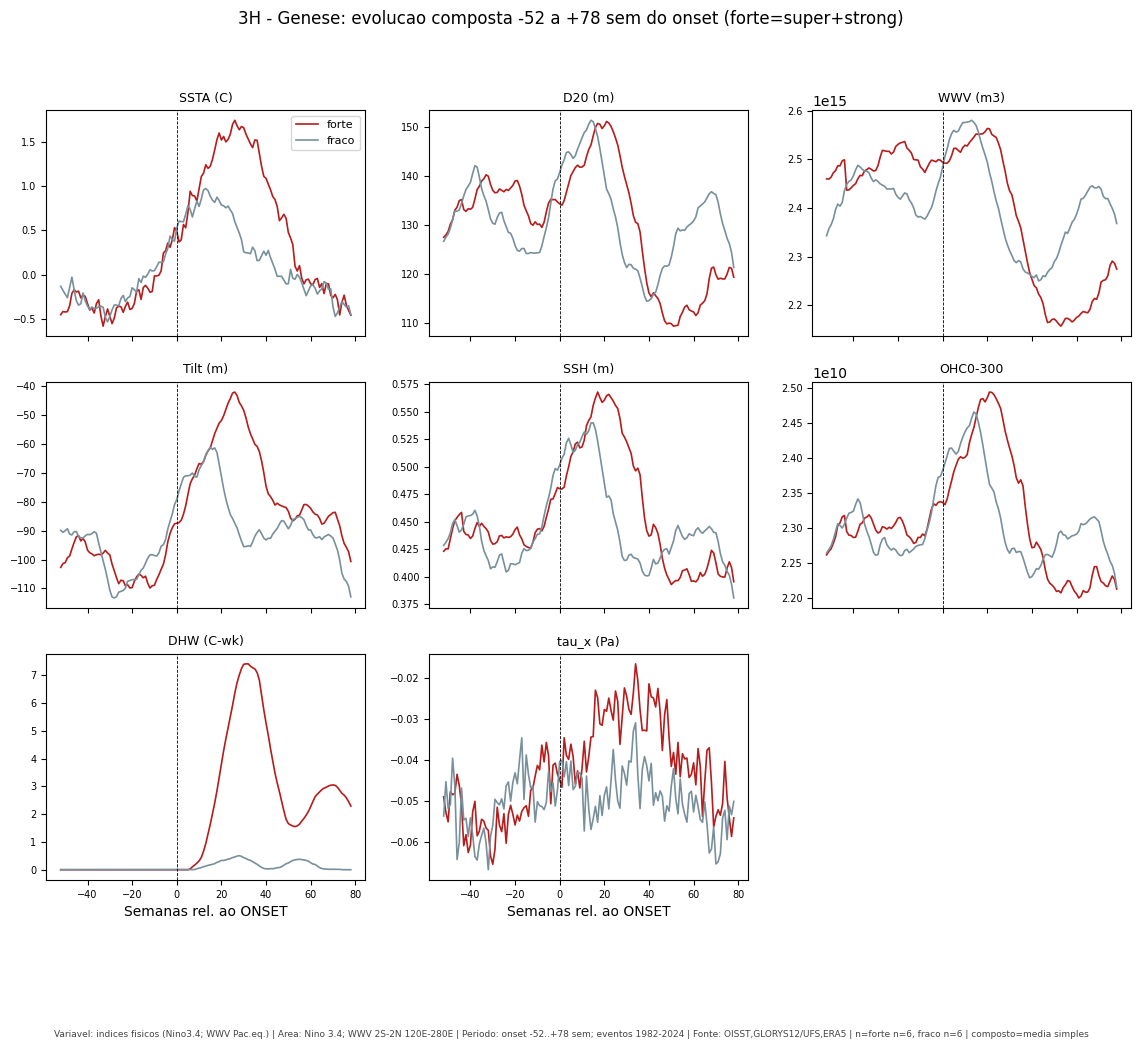

In [2]:
VARS=['nino34_ssta','d20_m','wwv','tilt_m','ssh_m','ohc_0_300','dhw_12w','tau_x_proxy_nino34_pa']; LAGS=list(range(-52,79))
def onset_al(s,o):
    i=s.index.get_indexer([o],method='nearest')[0]; seg=s.iloc[max(0,i-52):i+79]
    rel=((seg.index-s.index[i]).days/7).round().astype(int); return pd.Series(seg.values,index=rel).reindex(LAGS)
comps={g:pd.DataFrame({v:pd.DataFrame([onset_al(w[v],e.event_start) for _,e in gg.iterrows()]).mean() for v in VARS}) for g,gg in ev.groupby('grupo')}
pd.concat(comps,names=['grupo','sem_rel_onset']).to_csv(u.STATS/'phase3H_compostos_onset.csv')
lab={'nino34_ssta':'SSTA (C)','d20_m':'D20 (m)','wwv':'WWV (m3)','tilt_m':'Tilt (m)','ssh_m':'SSH (m)','ohc_0_300':'OHC0-300','dhw_12w':'DHW (C-wk)','tau_x_proxy_nino34_pa':'tau_x (Pa)'}
fig,axes=plt.subplots(3,3,figsize=(14,10),sharex=True)
for ax,v in zip(axes.flat,VARS):
    for g,cor in [('forte','#b71c1c'),('fraco','#78909c')]: ax.plot(LAGS,comps[g][v],color=cor,label=g,lw=1.2)
    ax.axvline(0,color='k',ls='--',lw=.6); ax.set_title(lab[v],fontsize=9); ax.tick_params(labelsize=7)
axes.flat[0].legend(fontsize=8)
for ax in axes[-1]: ax.set_xlabel('Semanas rel. ao ONSET')
for ax in axes.flat[len(VARS):]: ax.axis('off')
fig.suptitle('3H - Genese: evolucao composta -52 a +78 sem do onset (forte=super+strong)')
u.stamp_caption(fig,variavel='indices fisicos (Nino3.4; WWV Pac.eq.)',area='Nino 3.4; WWV 2S-2N 120E-280E',periodo='onset -52..+78 sem; eventos 1982-2024',fonte='OISST,GLORYS12/UFS,ERA5',n='forte n=6, fraco n=6',extra='composto=media simples')
u.save_fig(fig,'phase3H_compostos_onset.png'); plt.show()

[figura] data/processed/figures/fase3/phase3H_ciclo_vida.png


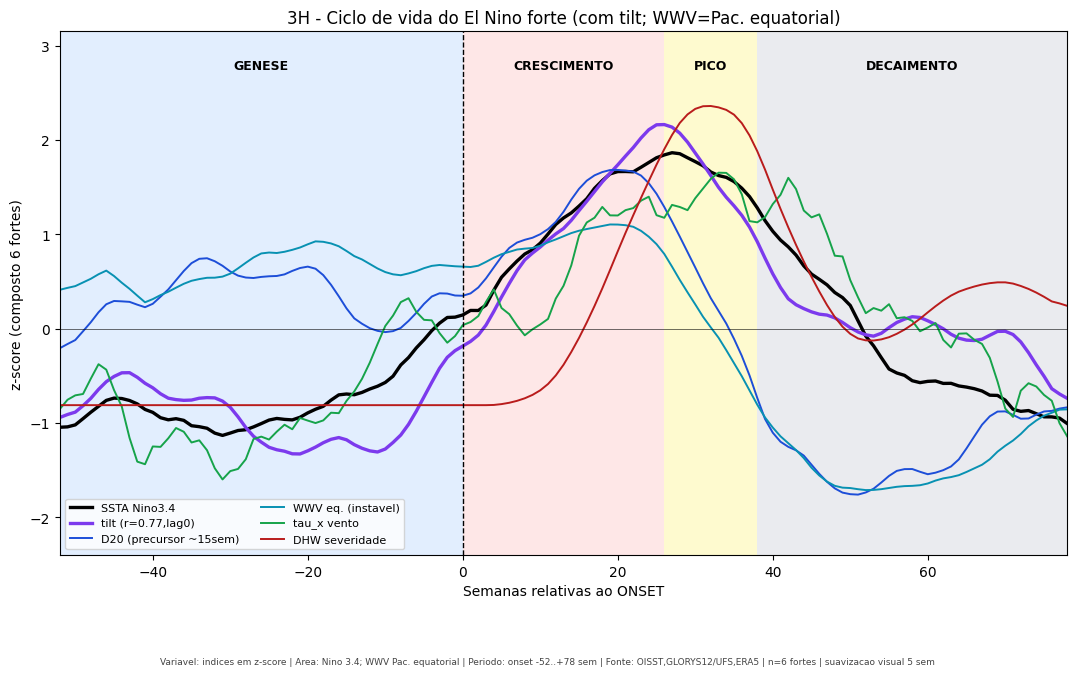

In [3]:
# storyline z-score COM tilt
zc=['nino34_ssta','tilt_m','d20_m','wwv','tau_x_proxy_nino34_pa','dhw_12w']
z=((comps['forte'][zc]-comps['forte'][zc].mean())/comps['forte'][zc].std()).rolling(5,center=True,min_periods=1).mean()
fases=[(-52,0,'#dbeafe','GENESE'),(0,26,'#fee2e2','CRESCIMENTO'),(26,38,'#fef9c3','PICO'),(38,78,'#e5e7eb','DECAIMENTO')]
cores={'nino34_ssta':('#000','SSTA Nino3.4'),'tilt_m':('#7c3aed','tilt (r=0.77,lag0)'),'d20_m':('#1d4ed8','D20 (precursor ~15sem)'),'wwv':('#0891b2','WWV eq. (instavel)'),'tau_x_proxy_nino34_pa':('#16a34a','tau_x vento'),'dhw_12w':('#b91c1c','DHW severidade')}
fig,ax=plt.subplots(figsize=(13,6.8))
for x0,x1,c,r in fases: ax.axvspan(x0,x1,color=c,alpha=.8,lw=0); ax.text((x0+x1)/2,2.75,r,ha='center',fontsize=9,weight='bold')
for v,(c,l) in cores.items(): ax.plot(z.index,z[v],color=c,lw=2.4 if v in('nino34_ssta','tilt_m') else 1.4,label=l)
ax.axvline(0,color='k',ls='--',lw=1); ax.axhline(0,color='k',lw=.4); ax.set_xlim(-52,78); ax.set_ylim(-2.4,3.15)
ax.set_xlabel('Semanas relativas ao ONSET'); ax.set_ylabel('z-score (composto 6 fortes)'); ax.legend(loc='lower left',fontsize=8,ncol=2)
ax.set_title('3H - Ciclo de vida do El Nino forte (com tilt; WWV=Pac. equatorial)')
u.stamp_caption(fig,variavel='indices em z-score',area='Nino 3.4; WWV Pac. equatorial',periodo='onset -52..+78 sem',fonte='OISST,GLORYS12/UFS,ERA5',n='6 fortes',extra='suavizacao visual 5 sem')
u.save_fig(fig,'phase3H_ciclo_vida.png'); plt.show()

In [4]:
from scipy.stats import spearmanr
marcos=[-26,-13,0]; rows=[]
for g,gg in ev.groupby('grupo'):
    for v in VARS:
        vals={m:[] for m in marcos}
        for _,e in gg.iterrows():
            s=onset_al(w[v],e.event_start)
            for m in marcos: vals[m].append(s.loc[m-2:m+2].mean())
        row={'grupo':g,'variavel':v}
        for m in marcos:
            a=pd.Series(vals[m]).dropna(); row[f'media_{m}s']=round(a.mean(),3); row[f'range_{m}s']=f'{a.min():.2f}..{a.max():.2f}'
        rows.append(row)
u.save_table(pd.DataFrame(rows),'phase3H_estado_precursor_por_classe.csv',index=False)
rows=[]
for v in VARS:
    pre=[];it=[]
    for _,e in ev.iterrows():
        s=onset_al(w[v],e.event_start); pre.append(s.loc[-26:0].mean()); it.append(e.peak_monthly_ssta_c)
    m=pd.notna(pre); rho,p=spearmanr(pd.Series(pre)[m],pd.Series(it)[m])
    rows.append({'variavel':v,'spearman_rho':round(float(rho),3),'p_bruto':round(float(p),3),'n':int(m.sum())})
sep=pd.DataFrame(rows).sort_values('spearman_rho',key=abs,ascending=False); u.save_table(sep,'phase3H_separacao_genese.csv',index=False)
print('SEPARACAO NA GENESE (Spearman estado precursor -26..0 vs intensidade final):')
for _,r in sep.iterrows(): print(f"  {r.variavel:22s} rho={r.spearman_rho:+.2f} (p={r.p_bruto:.2f})")

[tabela] data/processed/parquet/statistics/phase3H_estado_precursor_por_classe.csv
[tabela] data/processed/parquet/statistics/phase3H_separacao_genese.csv
SEPARACAO NA GENESE (Spearman estado precursor -26..0 vs intensidade final):
  d20_m                  rho=+0.52 (p=0.09)
  ohc_0_300              rho=+0.29 (p=0.35)
  wwv                    rho=+0.23 (p=0.47)
  tau_x_proxy_nino34_pa  rho=+0.20 (p=0.53)
  tilt_m                 rho=+0.20 (p=0.53)
  ssh_m                  rho=+0.15 (p=0.65)
  nino34_ssta            rho=+0.10 (p=0.75)
  dhw_12w                rho=+nan (p=nan)


/sessions/wonderful-cool-gates/tmp/ipykernel_11/4166472260.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  m=pd.notna(pre); rho,p=spearmanr(pd.Series(pre)[m],pd.Series(it)[m])


**Leitura do 3H.** Antes do onset, o que separa fortes de fracos e a **recarga subsuperficial**: D20/WWV/OHC mais altos ~26 sem antes. O melhor ordenador da intensidade final e o **D20 pre-onset (Spearman ~0.52)**. Na superficie (SSTA/DHW) fortes e fracos sao indistinguiveis na genese. Narrativa: recarga avisa (meses antes) -> vento acopla (durante) -> subsuperficie descarrega (no pico) -> DHW registra (depois).